In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from mixed_naive_bayes import MixedNB
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ( confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report )
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [13]:
health_stroke=pd.read_csv("health_stroke_dataset.csv")
health_stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [14]:
#The dimensions of the dataset;  
print('The Shape:',health_stroke.shape)

The Shape: (5110, 12)


In [15]:
#The names of all variables.
print(health_stroke.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [16]:
#The data type of each variable;
print(health_stroke.dtypes)

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [17]:
#The number of missing values in each variable;  
print(health_stroke.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [18]:
#The number of duplicated observations;  
print('Number of duplicates:', health_stroke.duplicated().sum())

Number of duplicates: 0


In [19]:
#Descriptive statistics for all variables; 
health_stroke.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [20]:
health_stroke["bmi"] = health_stroke["bmi"].fillna(health_stroke["bmi"].mean()) 
health_stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [21]:
#Encoding

encoder = LabelEncoder() 
health_stroke["ever_married"] = encoder.fit_transform(health_stroke["ever_married"]) 
health_stroke[["id","ever_married"]].head()

,id,ever_married
0,9046,1
1,51676,1
2,31112,1
3,60182,1
4,1665,1


In [22]:
#ordinal
health_stroke = pd.get_dummies( 
    health_stroke, 
    columns=["gender", "work_type",],  
    drop_first=False, dtype=int 
) 
 
health_stroke.head()

,id,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,9046,67.0,0,1,1,Urban,228.69,36.600000,formerly smoked,1,0,1,0,0,0,1,0,0
1,51676,61.0,0,0,1,Rural,202.21,28.893237,never smoked,1,1,0,0,0,0,0,1,0
2,31112,80.0,0,1,1,Rural,105.92,32.500000,never smoked,1,0,1,0,0,0,1,0,0
3,60182,49.0,0,0,1,Urban,171.23,34.400000,smokes,1,1,0,0,0,0,1,0,0
4,1665,79.0,1,0,1,Rural,174.12,24.000000,never smoked,1,1,0,0,0,0,0,1,0


In [23]:
health_stroke = pd.get_dummies( 
    health_stroke, 
    columns=["Residence_type", "smoking_status"],  
    drop_first=False, dtype=int 
) 
 
health_stroke.head()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,1,228.69,36.600000,1,0,1,...,0,1,0,0,0,1,0,1,0,0
1,51676,61.0,0,0,1,202.21,28.893237,1,1,0,...,0,0,1,0,1,0,0,0,1,0
2,31112,80.0,0,1,1,105.92,32.500000,1,0,1,...,0,1,0,0,1,0,0,0,1,0
3,60182,49.0,0,0,1,171.23,34.400000,1,1,0,...,0,1,0,0,0,1,0,0,0,1
4,1665,79.0,1,0,1,174.12,24.000000,1,1,0,...,0,0,1,0,1,0,0,0,1,0


In [24]:
health_stroke.drop("id",axis=1,inplace=True)
health_stroke.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,228.69,36.600000,1,0,1,0,...,0,1,0,0,0,1,0,1,0,0
1,61.0,0,0,1,202.21,28.893237,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,80.0,0,1,1,105.92,32.500000,1,0,1,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,1,171.23,34.400000,1,1,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,1,174.12,24.000000,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0


In [25]:
#Scaling numerical variables
scaler = StandardScaler() 
health_stroke[["age", "avg_glucose_level","bmi"]] = scaler.fit_transform( 
health_stroke[["age","avg_glucose_level","bmi"]] 
) 
health_stroke.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051434,0,1,1,2.706375,1.001234e+00,1,0,1,0,...,0,1,0,0,0,1,0,1,0,0
1,0.786070,0,0,1,2.121559,4.615554e-16,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1.626390,0,1,1,-0.005028,4.685773e-01,1,0,1,0,...,0,1,0,0,1,0,0,0,1,0
3,0.255342,0,0,1,1.437358,7.154182e-01,1,1,0,0,...,0,1,0,0,0,1,0,0,0,1
4,1.582163,1,0,1,1.501184,-6.357112e-01,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0


In [26]:
# Separate predictors and target
# ---------------------------------------------------

# The target column in this dataset is named 'target'
X = health_stroke.drop("stroke", axis=1)
y = health_stroke["stroke"]

In [27]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
print("\nTraining sample size:", len(X_train))
print("Test sample size:", len(X_test))


Training sample size: 4088
Test sample size: 1022


In [28]:
# 3. Model Development Logistic Regression 
# ==================================================
model = LogisticRegression(max_iter=1000)

# Train the model using only the training data
model.fit(X_train, y_train)

# ==================================================
#. Make predictions using the test data
# ==================================================

# Predicted classes
y_pred = model.predict(X_test)

param_logistic_regression = { 
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty":["l2"],
    "solver":["lbfgs"],  
} 
grid_logistic_regression = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_logistic_regression,  
    cv=5, 
    scoring='accuracy' 
) 
grid_logistic_regression.fit(X_train, y_train) 
print(grid_logistic_regression.best_params_)
#. Calculate model evaluation
# ==================================================
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:")
print(accuracy)# ==================================================


# Precision 
precision = precision_score(y_test, y_pred) 
print(f"Precision: {precision:.4f}") 

# Recall 
recall = recall_score(y_test, y_pred) 
print(f"Recall: {recall:.4f}") 

# F1-score 
f1 = f1_score(y_test, y_pred) 
print(f"F1-score: {f1:.4f}") 
# ==================================================
#. Display the classification report
# ==================================================
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Class 0", "Class 1"],
        zero_division=0
    ))
# Display the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

{'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}

Accuracy:
0.952054794520548
Precision: 1.0000
Recall: 0.0200
F1-score: 0.0392

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      1.00      0.98       972
     Class 1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

Confusion Matrix:
[[972   0]
 [ 49   1]]



AUC Score:
0.8426131687242798


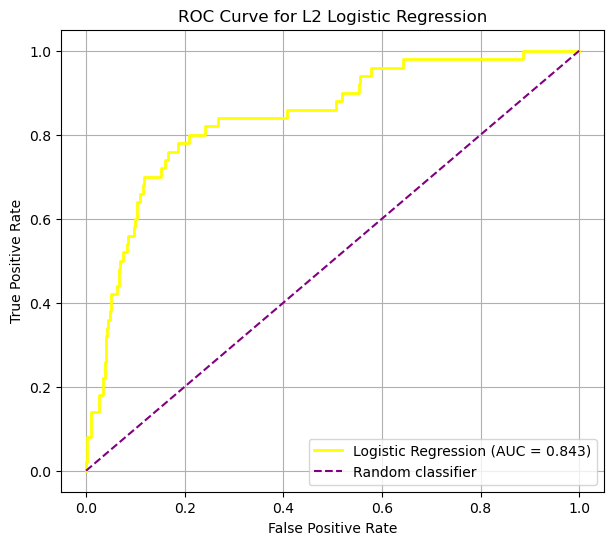


Model intercept:
[-3.8842189]

Model coefficients:
[[ 1.6465313   0.44506677  0.19095633 -0.25225024  0.17553009  0.01795387
  -0.02590176  0.03847374 -0.01913793  0.01115292 -0.06490393  0.07790807
  -0.1905502   0.15982717 -0.04374761  0.03718165 -0.07108068  0.04933018
  -0.15785694  0.17304148]]


In [29]:
#. Calculate the ROC curve and AUC
# ==================================================
# Probability of belonging to class 1
y_probability = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

auc_score = roc_auc_score(y_test, y_probability)

print("\nAUC Score:")
print(auc_score)

# ==================================================
#. Plot the ROC curve
# ==================================================
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.3f})", color="yellow"
)
# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier", color="purple"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for L2 Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ==================================================
#  Display the model parameters
# ==================================================
print("\nModel intercept:")
print(model.intercept_)

print("\nModel coefficients:")
print(model.coef_)

In [30]:
# Model Development Naive Bayes( Mixed naive bayes)
categorical_features=[1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
mixed_nb=MixedNB(categorical_features=categorical_features)
mixed_nb.fit(X_train.values, y_train.values)
y_pred_nb=mixed_nb.predict(X_test.values)
print(mixed_nb.get_params())

{'categorical_features': array([ 1,  2,  3,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]), 'max_categories': array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]), 'alpha': 0.5, 'priors': array([0.95132094, 0.04867906]), 'var_smoothing': 1e-09}


In [31]:
# Train the model using only the training data
model = MixedNB()

model.fit(X_train, y_train)

# ==================================================
#. Make predictions using the test data
# ==================================================

# Predicted classes
y_pred = model.predict(X_test)

categorical_features=[1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
mixed_nb=MixedNB(categorical_features,alpha=0.5,var_smoothing= 1e-09)
mixed_nb.fit(X_train.values, y_train.values)
y_pred=mixed_nb.predict(X_test.values)    

# ==================================================
#. Calculate model evaluation
# ==================================================
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:")
print(accuracy)

# Precision 
precision = precision_score(y_test, y_pred) 
print(f"Precision: {precision:.4f}") 
# Recall 
recall = recall_score(y_test, y_pred) 
print(f"Recall: {recall:.4f}") 

# F1-score 
f1 = f1_score(y_test, y_pred) 
print(f"F1-score: {f1:.4f}") 
# ==================================================
#. Display the classification report
# ==================================================
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Class 0", "Class 1"],
        zero_division=0
    ))
# Display the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy:
0.8933463796477495
Precision: 0.1895
Recall: 0.3600
F1-score: 0.2483

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      0.92      0.94       972
     Class 1       0.19      0.36      0.25        50

    accuracy                           0.89      1022
   macro avg       0.58      0.64      0.60      1022
weighted avg       0.93      0.89      0.91      1022

Confusion Matrix:
[[895  77]
 [ 32  18]]



AUC Score:
0.8120576131687243


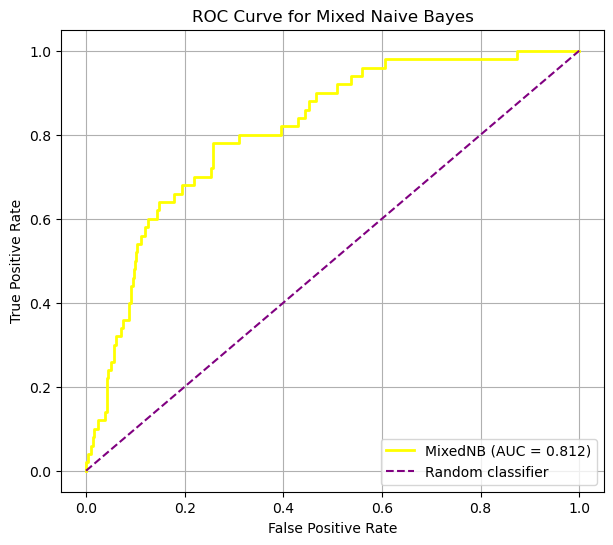

In [32]:
#. Calculate the ROC curve and AUC
# ==================================================
# Probability of belonging to class 1
y_probability = mixed_nb.predict_proba(X_test.values)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

auc_score = roc_auc_score(y_test, y_probability)

print("\nAUC Score:")
print(auc_score)

# ==================================================
#. Plot the ROC curve
# ==================================================
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MixedNB (AUC = {auc_score:.3f})", color="yellow"
)
# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier", color="purple"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Mixed Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [33]:
# Model Development Support Vector Machine(SVM)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train the model using only the training data
svm=SVC()
svm.fit(X_train, y_train)

# ==================================================
#. Make predictions using the test data
# ==================================================

# Predicted classes
y_pred =svm.predict(X_test)
print(svm.get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. Create a Pipeline with StandardScaler + SVC
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced'))
])

# 2. Define grid parameters (prefixed with 'svm__' for the pipeline step)
param_svm = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1]
}

# 3. Set up Grid Search targeting F1 score for minority class
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_svm,
    scoring='f1',
    cv=5,
    refit=True,
    verbose=1
)

# 4. Train Grid Search
grid_svm.fit(X_train, y_train)

# Print Best Parameters
print("Best Params:", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

# --------------------------------------------------
# 5. Make predictions using the BEST tuned model
# --------------------------------------------------
y_pred = grid_svm.predict(X_test)

# 6. Print Evaluation Metrics
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"], zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'svm__C': 10, 'svm__gamma': 0.001}
Best CV F1-Score: 0.2191021196747102

Accuracy:  0.7319
Precision: 0.1603
Recall:    0.8065
F1-score:  0.2674

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.73      0.84       960
     Class 1       0.16      0.81      0.27        62

    accuracy                           0.73      1022
   macro avg       0.57      0.77      0.55      1022
weighted avg       0.93      0.73      0.80      1022


Confusion Matrix:
[[698 262]
 [ 12  50]]


In [35]:
#Training the model
knn = KNeighborsClassifier() 
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [36]:
param_knn ={
    'n_neighbors':[3,5,7,9,11,13],
    'metric':['euclidean','manhattan'],
    'weights':['uniform','distance']
}
grid_knn=GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_knn,
    cv=5,
    scoring='accuracy'
)
#fit on training data
grid_knn.fit(X_train,y_train)

#print results
print("Best Prameters:",grid_knn.best_params_)
print("Best CV Accuracy:", grid_knn.best_score_)

Best Prameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best CV Accuracy: 0.9542565830622498


In [37]:
# Predict the test data
model = Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier(n_neighbors=9))])

model.fit(X_train, y_train) 

y_pred = model.predict(X_test)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")
# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")
# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix
[[959   1]
 [ 60   2]]
Accuracy: 0.9403
Precision: 0.6667
Recall: 0.0323
F1-score: 0.0615

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.67      0.03      0.06        62

    accuracy                           0.94      1022
   macro avg       0.80      0.52      0.52      1022
weighted avg       0.92      0.94      0.91      1022

